Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. Rozważ zbiór danych [Air Quality](https://archive.ics.uci.edu/dataset/360/air+quality)
1. [0-3 pkt] Dokonaj wstępnego przetwarzania danych. Skomentuj poszczególne kroki i podjęte decyzje. **Uwagi**: 
   1. kluczowe jest zapoznanie się z opisem zbioru danych
   1. nie interesuje nas tu zależność czasowa - nie traktujemy tego zbioru jako serii czasowej. Jednak rozważ użycie miesiąca jako zmiennej kategorycznej
   1. jaką inną zmienną powinniśmy wyłączyć z analizy? Dlaczego?
   1. jako zmienną zależną (*target*) rozważ sumę koncentracji poszczególnych związków (ozn. `GT`). Czy sumę liczymy przed czy po skalowaniu cech?
1. [0-2 pkt] Użyj:
   1. modelu liniowego
   1. modelu liniowego z regularyzcją L1
   1. modelu liniowego z regularyzcją L2
   1. regresji Hubera
1. [0-2 pkt] Porównaj poszczególne modele dla domyślnych parametrów oraz różnych wartości regularyzacji (użyj [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html))
1. [0-1 pkt] Skomentuj uzyskane wyniki m.in. odnośnie wartości RMSE i MAE oraz czasu treningu
1. [0-1 pkt] Zbadaj wpływ wstępnego przetwarzania danych (np. wpływu skorelowanych cech, usuwania zmiennych katagorycznych, normalizacji) na wyniki. W tym celu możesz użyć klasy [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
1. [0-1 pkt] Zwizualizuj wartości parametrów, porównując wszystkie modele razem. Jak wybór parametrów wpływa na osiągi modelu?
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

Na początku importuję biblioteki potrzebne do analizy danych i budowy modeli uczenia maszynowego. `pandas` i `numpy` służą do przetwarzania danych, a `matplotlib` i `seaborn` do wizualizacji. `sklearn` służy do budowy modeli regresyjnych.

In [2]:
air_quality = fetch_ucirepo(id=360)

X = air_quality.data.features 
y = air_quality.data.targets 

df = pd.concat([X, y], axis=1)

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Następnie pobieram dane ze zbiorem danych Air Quality z UCI ML repo. Oddzielam cechy i target i łączę w jeden dataframe.

Zbiór danych Air Quality zawiera pomiary jakości powietrza zarejestrowane przez różne sensory. Oprócz pomiarów sensorów znajdują się również dane na temat pogody jak temperatura, wilgotność czy absolutna wilgotność.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [4]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [5]:
df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

W opisie zbioru danych wspomniano, że brakujące wartości są reprezentowane przez `-200`. Jak widać wyżej, w każdym polu występuje choć raz wartość `-200`. W związku z tym musimy potraktować te wartości jako brakujące i abyśmy mogli lepiej przetwarzać te dane, zastąpimy je przez `NaN`.

In [6]:
df = df.replace(-200, np.nan)

In [7]:
df.isna().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Jak widać wyżej, mamy sporo brakujących wartości

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["month"] = df["Date"].dt.month.astype("category")

df = df.drop(columns=["Date", "Time"])

Skoro nie interesuje nas zależność czasowa, możemy wywalić kolumny Date i Time. Jednakże, możemy wcześniej z Date wyciągnąć miesiąc, gdyż dane o zanieczyszczeniu powietrza mogą zależeć od danego miesiąca (pory roku).

In [9]:
gt_columns = [col for col in df.columns if "GT" in col]
gt_columns

['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

In [11]:
df["target"] = df[gt_columns].sum(axis=1)

In [12]:
df = df.drop(columns=gt_columns)

In [14]:
df = df.dropna()

Oprócz zmiennych czasowych, usuwamy z cech wszystkie kolumny GT, bo są one pomiarami tych samych gazów, które tworzą target. Interesuje nas więc ich suma, tak jak było wspomniane w treści zadania. 

Sumę GT musimy policzyć przed skalowaniem, gdyż skalowanie może nam zmienić wartości, przez co nie będą one miały sensu fizycznego.

Zdecydowałem się także usunąć wiersze, które zawierały brakujące wartości, aby zapewnić poprawne działanie modeli regresyjnych.

In [15]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Pierw dokonuję podziału zbioru danych na zbiór treningowy i testowy w proporcjach 80/20.

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso (L1)": Lasso(),
    "Ridge (L2)": Ridge(),
    "Huber": HuberRegressor()
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    start = time.time()

    pipe.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "train_time": train_time
    })

results_df = pd.DataFrame(results)

results_df

,model,RMSE,MAE,train_time
0,Linear Regression,169.547333,113.179969,0.044989
1,Lasso (L1),169.933882,113.667408,0.025084
2,Ridge (L2),169.548820,113.190214,0.023228
3,Huber,173.131956,110.839993,0.060898


Do porównania metod regresji zastosowano 4 modele: klasyczną regresję liniową, regresję Lasso (z regularyzacją L1), regresję Ridge (z regularyzacją L2) oraz regresję Hubera. Wszystkie modele zostały uruchomione w pipeline zawierającym standaryzację cech. Do oceny jakości modelu wykorzystano metryki RMSE i MAE. Dodatkowo zmierzyłem czas treningu modeli.

Porównując modele można zauważyć, że regresja liniowa i regresja Ridge osiągają podobne wyniki. W obu przypadkach mamy podobne RMSE i MAE, co sugeruje, że zastosowanie regularyzacji L2 nie przynosi istotnej poprawy jakości predykcji. Być może model liniowy nie cierpi bardzo na problem nadmiernego dopasowania.

Model Lasso uzyskał nieco gorsze wyniki. Być może wynika to z faktu, że regularyzacja L1 może eliminować część cech poprzez zerowanie współczynników, co może prowadzić do utraty części istotnych informacji dla predykcji

Model Hubera osiągnął najwyższą wartość RMSE i najniższą MAE. Oznacza to, że model ten lepiej radzi sobie z typowymi błędami predykcji, lecz dla niektórych obserwacji może generować większe błędy. Regresja Hubera jest bardziej odporna na obserwacje odstające.

Wszystkie modele trenowały się dość szybko. Różnice między czasami treningu są niewielkie i raczej nie mają większego znaczenia dla małego zbioru danych. Najdłużej trenowała się regresja liniowa, a najszybszy był model Ridge.

In [17]:
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [18]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

grid_lasso = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5, 
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

results_lasso = pd.DataFrame(grid_lasso.cv_results_)

table_lasso = results_lasso[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score"
]].copy()

table_lasso["rmse"] = np.sqrt(-table_lasso["mean_test_score"])

print("\nLasso - wyniki dla różnych alpha:")
print(table_lasso)


Lasso - wyniki dla różnych alpha:
   param_model__alpha  mean_test_score  std_test_score        rmse
0                0.01    -27452.523461     1783.805418  165.688031
1                0.10    -27451.293406     1779.835939  165.684319
2                1.00    -27520.717091     1723.780118  165.893692
3               10.00    -28981.373183     1367.345390  170.239165
4              100.00    -47692.868953     1248.297423  218.386971


W przypadku regresji Lasso widzimy wyraźny wpływ parametru alpha na jakość modelu. Najlepszy wynik RMSE uzyskano dla alpha = 0.01. Wraz ze wzrostem parametru regularyzacji, jakość modelu zaczyna się pogarszać. Bardzo duża regularyzacja (alpha=100) znacznie pogarsza wyniki. Oznacza to, że zbyt silna regularyzacja w modelu Lasso prowadzi do nadmiernego upraszczania modelu i utraty informacji, co skutkuje większym błędem predykcji.

In [19]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

grid_ridge = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

results_ridge = pd.DataFrame(grid_ridge.cv_results_)

table_ridge = results_ridge[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score"
]].copy()

table_ridge["rmse"] = np.sqrt(-table_ridge["mean_test_score"])

print("\nRidge - wyniki dla różnych alpha:")
print(table_ridge)


Ridge - wyniki dla różnych alpha:
   param_model__alpha  mean_test_score  std_test_score        rmse
0                0.01    -27452.837777     1784.173913  165.688979
1                0.10    -27452.810581     1783.978417  165.688897
2                1.00    -27452.580620     1782.039747  165.688203
3               10.00    -27454.016068     1764.155318  165.692535
4              100.00    -27613.246010     1666.190747  166.172338


W przypadku regresji Ridge, wpływ parametru alpha jest mniejszy niż w Lasso. Dla różnych wartości alpha, RMSE pozostaje mniej więcej na tym samym poziomie. Dopiero dla alpha=100 widać lekkie pogorszenie modelu. Oznacza to, że model Ridge jest całkiem stabilny względem zmian parametru regularyzacji.

In [20]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", HuberRegressor())
])

grid_huber = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_huber.fit(X_train, y_train)

results_huber = pd.DataFrame(grid_huber.cv_results_)

table_huber = results_huber[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score"
]].copy()

table_huber["rmse"] = np.sqrt(-table_huber["mean_test_score"])

print("\nHuber - wyniki dla różnych alpha:")
print(table_huber)


Huber - wyniki dla różnych alpha:
   param_model__alpha  mean_test_score  std_test_score        rmse
0                0.01    -28283.577414     2089.526356  168.177220
1                0.10    -28243.206011     2067.893293  168.057151
2                1.00    -28289.159465     1947.881282  168.193815
3               10.00    -29412.595352     1677.048111  171.501007
4              100.00    -45983.599807     1069.421636  214.437869


Regresja Hubera osiąga lekko gorsze wyniki niż modele liniowe z regularyzacją L1 i L2. Zmiana parametru alpha w zakresie 0.01-1 nie powoduje dużych zmian RMSE, ale dla większych wartości jakość predykcji się pogarsza.

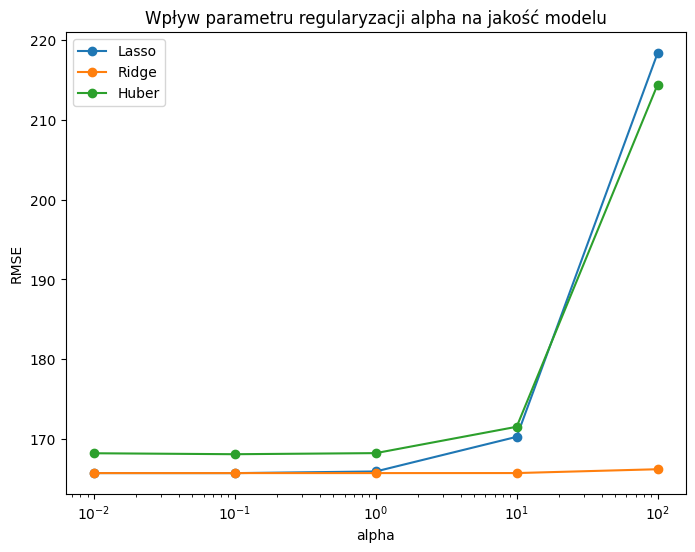

In [21]:
plt.figure(figsize=(8, 6))

plt.plot(
    table_lasso["param_model__alpha"],
    table_lasso["rmse"],
    marker="o",
    label="Lasso"
)

plt.plot(
    table_ridge["param_model__alpha"],
    table_ridge["rmse"],
    marker="o",
    label="Ridge"
)

plt.plot(
    table_huber["param_model__alpha"],
    table_huber["rmse"],
    marker="o",
    label="Huber"
)

plt.xscale("log")

plt.xlabel("alpha")
plt.ylabel("RMSE")
plt.title("Wpływ parametru regularyzacji alpha na jakość modelu")

plt.legend()
plt.show()

Najlepsze wyniki uzyskały modele Lasso i Ridge z RMSE około 165,69. Huber Regressor osiągnął nieco gorszy wynik. Model Ridge okazał się najbardziej stabilny wobec zmian alpha. Model Lasso jest za to bardziej wrażliwy na duże wartości alpha, które szybko pogarszają jakość predykcji. Dla wszystkich metod zbyt duża regularyzacja powoduje pogorszenie jakości modelu, gdyż ogranicza jego zdolność do dopasowania danych.

Niewielkie różnice między Ridge i Lasso mogą sugerować, że liczba istotnych cech w modelu jest stosunkowo duża, przez co selekcja cech wykonywana przez Lasso nie przynosi istotnej poprawy jakości modelu.

In [22]:
pipe_no_scaling = Pipeline([
    ("model", Ridge())
])

pipe_no_scaling.fit(X_train, y_train)

pred = pipe_no_scaling.predict(X_test)

rmse_no_scaling = np.sqrt(mean_squared_error(y_test, pred))

pipe_scaling = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

pipe_scaling.fit(X_train, y_train)

pred = pipe_scaling.predict(X_test)
rmse_scaling = np.sqrt(mean_squared_error(y_test, pred))

print(f"RMSE bez skalowania: {rmse_no_scaling:.4f}")
print(f"RMSE ze skalowaniem: {rmse_scaling:.4f}")

RMSE bez skalowania: 169.5491
RMSE ze skalowaniem: 169.5488


In [24]:
corr = X_train.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Usuwane cechy z powodu wysokiej korelacji:", to_drop)

X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

pipe_reduced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

pipe_reduced.fit(X_train_reduced, y_train)

pred_reduced = pipe_reduced.predict(X_test_reduced)

rmse_reduced = np.sqrt(mean_squared_error(y_test, pred_reduced))

X_no_cat = X.drop(columns=["month"])

pipe_no_cat = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

pipe_no_cat.fit(X_no_cat.loc[X_train.index], y_train)
pred_no_cat = pipe_no_cat.predict(X_no_cat.loc[X_test.index])
rmse_no_cat = np.sqrt(mean_squared_error(y_test, pred_no_cat))

print(f"RMSE bez cechy 'month': {rmse_no_cat:.4f}")

Usuwane cechy z powodu wysokiej korelacji: ['PT08.S5(O3)']
RMSE bez cechy 'month': 169.8837


In [25]:
results_preprocessing = pd.DataFrame({
    "model": ["Ridge no scaling", "Ridge with scaling", 
              "Ridge with feature reduction", "Ridge without 'month'"],
    "RMSE": [rmse_no_scaling, rmse_scaling, rmse_reduced, rmse_no_cat]
})

results_preprocessing

,model,RMSE
0,Ridge no scaling,169.549110
1,Ridge with scaling,169.548820
2,Ridge with feature reduction,170.747838
3,Ridge without 'month',169.883680


Przeprowadziłem eksperyment porównujący działanie modelu Ridge dla trzech wariantów wstępnego przetwarzania danych: bez skalowania cech, ze skalowaniem, z usunięciem silnie skorelowanych  oraz z usunięciem zmiennej kategorycznej. W przypadku skalowania wynik RMSE nieznacznie się poprawia, aczkolwiek skalowanie cech nie ma istotnego wpływu na jakość predykcji modelu. Może to wynikać z faktu, że wartości cech w zbiorze są w podobnych zakresach lub po prostu model Ridge sobie dobrze radzi z różnicami.

W przypadku redukcji skorelowanych cech błąd RMSE nieznacznie wzrasta, co sugeruje, że usunięcie części cech mogło spowodować utratę pewnej ilości informacji istotnej dla modelu.

W przypadku usunięcia zmiennej "month" wynik RMSE nieznacznie się pogarsza, co sugeruje, że informacja o miesiącu może zawierać pewne informacje o sezonowości zanieczyszczeń powietrza. Uwzględnienie zmiennej kategorycznej pozwalaw lepszym stopniu dopasować się do danych.

# Zadanie dodatkowe [0-3] pkt

Użyj modelu liniowych efektów mieszanych w zadaniu wyżej:
1. Wykorzystaj API ze [statsmodels](https://www.statsmodels.org/stable/mixed_linear.html)
1. Użyj miesiąca jako zmiennej modelującej efekt losowy (potencjalny *bias*)
1. Skomentuj wyniki w porównaniu do zadania wyżej (miesiąc jako zmienna kategoryczna)

In [36]:
import statsmodels.formula.api as smf

df_renamed = df.rename(columns=lambda x: x.replace('.', '_').replace('(', '_').replace(')', '_'))

feature_cols = [c for c in df_renamed.columns if c not in ["target", "month"]]

formula = "target ~ " + " + ".join(feature_cols)

mixed_model = smf.mixedlm(
    formula, 
    data=df_renamed, 
    groups=df_renamed["month"]
)

mixed_result = mixed_model.fit()

print(mixed_result.summary())

y_true = df_renamed["target"]
y_pred = mixed_result.fittedvalues

rmse_mixed = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE MixedLM: {rmse_mixed:.4f}")

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   target     
No. Observations:   8991      Method:               REML       
No. Groups:         12        Scale:                25011.1873 
Min. group size:    596       Log-Likelihood:       -58318.7555
Max. group size:    1253      Converged:            Yes        
Mean group size:    749.2                                      
---------------------------------------------------------------
               Coef.   Std.Err.    z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------
Intercept     -591.957   35.475 -16.686 0.000 -661.488 -522.427
PT08_S1_CO_      0.480    0.031  15.558 0.000    0.420    0.541
PT08_S2_NMHC_    0.852    0.034  25.013 0.000    0.785    0.919
PT08_S3_NOx_     0.149    0.015   9.991 0.000    0.120    0.178
PT08_S4_NO2_    -0.495    0.025 -20.070 0.000   -0.543   -0.447
PT08_S5_O3_      0.106    0.013   8.306 0.000    0.08

C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


Użycie miesiąca jako efektu losowego pozwala uwzględnić sezonowe różnice w wartościach `target` bez wprowadzania wielu zmiennych jak w regresji Ridge. Model MixedLM lepiej uchwyca potencjalny bias wynikający z miesiąca. Obliczone RMSE dla MixedLM wynosi 157.98, co jest niższą wartością niż w modelach Ridge czy Lasso, co sugeruje lepsze dopasowanie i skuteczniejsze dopasowanie efektu miesiąca.
MixedLM jest korzystny, gdy chcemy modelować wpływ zmiennych grupujących jako efekt losowy zamiast dodawać je jako zwykłe zmienne kategoryczne w regresji liniowej.